# Explainable Predictive Maintenance — Exploration & SHAP

Turbofan engine failure prediction on NASA's **C-MAPSS FD001** dataset using
**XGBoost + SHAP**.

This notebook walks through the full analysis: loading and understanding the
data, framing the prediction problem, training a model with proper handling of
class imbalance, evaluating it with metrics that actually matter for
maintenance, and — the core of the project — explaining predictions with SHAP.

> **To reproduce:** place `train_FD001.txt` in `../data/` and run all cells.

The reusable logic lives in the `pdm` package (`../src/pdm/`); here we work
through it interactively to see and explain each step.

## 0. Setup

We import from our own installed `pdm` package where helpful, but also work
with the raw objects directly so every step is visible.

In [1]:
import sys
sys.path.append('../src')   # so `import pdm` works from the notebook

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from pdm import config, data, model, evaluate, explain

pd.set_option('display.max_columns', 30)

## 1. Load the data

The C-MAPSS files are whitespace-separated with no header. Each row is one
**engine** at one **cycle** (time step), with 3 operational settings and 21
sensor readings. Every engine in the training set runs from healthy operation
all the way to failure.

In [2]:
df = data.load_raw()
print("Shape:", df.shape)
df.head()

Shape: (20631, 26)


,unit,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


### How long does each engine live?

There are 100 engines. The spread of lifetimes is the whole reason this problem
needs machine learning — if every engine failed at the same cycle, a calendar
would do. The model's job is to read the sensor patterns and tell which engines
are degrading faster.

In [3]:
print("Number of engines:", df['unit'].nunique())
df.groupby('unit')['cycle'].max().describe()

Number of engines: 100


count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: cycle, dtype: float64

## 2. Frame the problem: from raw cycles to a prediction target

Raw `cycle` counts *elapsed* time — not useful to predict from directly. We
convert it into **Remaining Useful Life (RUL)**: since every training engine
runs to failure, RUL for any row is simply
`(that engine's max cycle) - (current cycle)`.

We then reframe as a **binary classification** matching the real maintenance
question: *"Will this engine fail within the next 30 cycles?"* — our
maintenance warning window.

In [4]:
df = data.add_labels(df)
df[['unit', 'cycle', 'RUL', 'fail_soon']].head()

,unit,cycle,RUL,fail_soon
0,1,1,191,0
1,1,2,190,0
2,1,3,189,0
3,1,4,188,0
4,1,5,187,0


### Class balance — a crucial detail

Most of any engine's life is spent *not* about to fail, so failures are rare.
This imbalance is central: it dictates how we train and, especially, how we
evaluate. A model that blindly predicts "healthy" would look accurate while
being useless.

In [5]:
counts = df['fail_soon'].value_counts()
print(counts)
print()
print((df['fail_soon'].value_counts(normalize=True) * 100).round(1), "(%)")

fail_soon
0    17531
1     3100
Name: count, dtype: int64

fail_soon
0    85.0
1    15.0
Name: proportion, dtype: float64 (%)


## 3. Feature selection: drop dead sensors

Several sensors in FD001 are constant (zero variance) — they carry no signal.
We confirm this empirically rather than assuming it, then drop them.

In [6]:
sensor_cols = [f'sensor_{i}' for i in range(1, 22)]
df[sensor_cols].std().sort_values()

sensor_1     0.000000e+00
sensor_19    0.000000e+00
sensor_18    0.000000e+00
sensor_10    0.000000e+00
sensor_16    3.469531e-18
sensor_5     5.329200e-15
sensor_6     1.388985e-03
sensor_15    3.750504e-02
sensor_8     7.098548e-02
sensor_13    7.191892e-02
sensor_21    1.082509e-01
sensor_20    1.807464e-01
sensor_11    2.670874e-01
sensor_2     5.000533e-01
sensor_12    7.375534e-01
sensor_7     8.850923e-01
sensor_17    1.548763e+00
sensor_3     6.131150e+00
sensor_4     9.000605e+00
sensor_14    1.907618e+01
sensor_9     2.208288e+01
dtype: float64

The sensors at (near-)zero standard deviation are floating-point-constant and
useless. The configured drop-list encodes exactly these, leaving 14 varying
sensors + 3 operational settings = **17 features**.

In [7]:
feature_cols = config.get_feature_cols()
print(f"{len(feature_cols)} features:")
print(feature_cols)

17 features:
['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21', 'op_setting_1', 'op_setting_2', 'op_setting_3']


## 4. The leakage-safe split (the most important methodological point)

The instinctive move — a random row-level `train_test_split` — is **wrong
here**. It would scatter rows from the *same engine* across train and test, so
the model effectively peeks at each engine's trajectory during training. Test
scores would look great and mean nothing.

The correct approach: split **by engine**. Some engines go entirely to train,
others entirely to test. No engine appears in both. (Enforced by an automated
test in `tests/test_data.py`.)

In [8]:
train_df, test_df = data.split_by_engine(df)
print(f"Train: {train_df['unit'].nunique()} engines, {len(train_df)} rows")
print(f"Test:  {test_df['unit'].nunique()} engines, {len(test_df)} rows")

X_train, y_train = data.get_xy(train_df)
X_test,  y_test  = data.get_xy(test_df)
print(f"Train positive rate: {y_train.mean():.3f}")
print(f"Test  positive rate: {y_test.mean():.3f}")

Train: 80 engines, 16527 rows
Test:  20 engines, 4104 rows
Train positive rate: 0.150
Test  positive rate: 0.151


## 5. Train XGBoost with imbalance correction

`scale_pos_weight` is set to the negative/positive ratio (~5.6). This tells
XGBoost that missing a real failure is ~5.6x costlier than a false alarm,
pushing it to actually catch the rare failures instead of defaulting to
"healthy".

In [9]:
clf = model.train(X_train, y_train)
print("scale_pos_weight used:", round(model.compute_scale_pos_weight(y_train), 2))
print("Training complete.")

scale_pos_weight used: 5.66
Training complete.


## 6. Evaluate — and why accuracy lies here

With ~85% healthy rows, a trivial "always healthy" model scores ~85% accuracy
while catching **zero** failures. So we look past accuracy to the **confusion
matrix** and, above all, **recall on the failure class** — the fraction of real
failures we actually caught. In maintenance, a missed failure (false negative)
is far costlier than a false alarm.

In [10]:
metrics = evaluate.evaluate(clf, X_test, y_test)

Accuracy (misleading on its own): 0.940

Confusion matrix [rows=actual, cols=predicted]:
               pred:Healthy  pred:FailSoon
  act:Healthy         3264           220
  act:FailSoon          26           594

Key metrics on the FAILURE class:
  recall    = 0.958  (fraction of real failures caught)
  precision = 0.730  (fraction of alarms that were real)
  f1        = 0.828


### Visualize the confusion matrix

The bottom-left cell (real failures we *missed*) is the one that should worry a
maintenance engineer most.

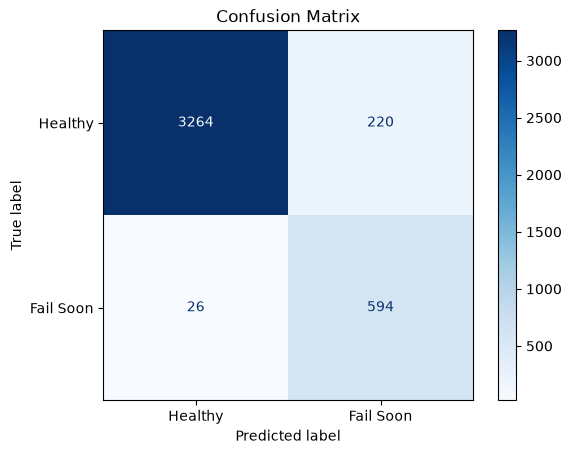

In [11]:
from sklearn.metrics import ConfusionMatrixDisplay

y_pred = clf.predict(X_test)
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=['Healthy', 'Fail Soon'], cmap='Blues'
)
plt.title('Confusion Matrix')
plt.show()

## 7. Explainability — SHAP global view

Now we open the black box. SHAP (from game theory) fairly distributes credit
for each prediction across the features: how much did each sensor push *this*
prediction toward "fail" (positive) or "healthy" (negative)?

The **global** summary shows which sensors drive failure predictions across all
engines. Each dot is an engine-row; red = high feature value, blue = low;
position left/right = push toward healthy/fail.

SHAP values shape: (4104, 17)


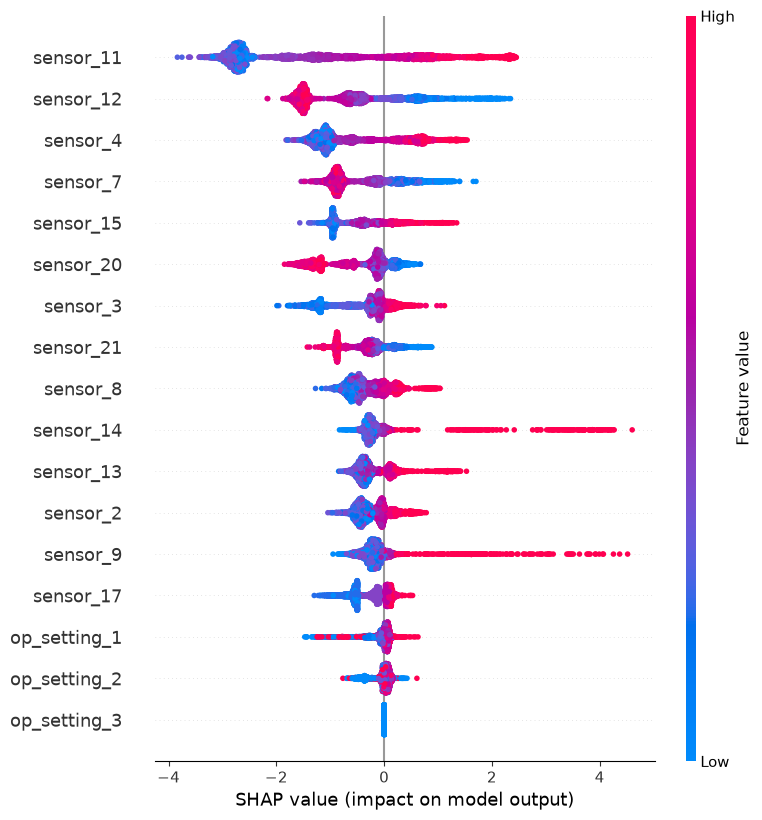

In [12]:
explainer = explain.build_explainer(clf)
shap_values = explainer.shap_values(X_test)
print("SHAP values shape:", shap_values.shape)

shap.summary_plot(shap_values, X_test, feature_names=feature_cols)

## 8. SHAP local view — why *this one engine*?

This is what makes SHAP valuable for maintenance: explaining a **single**
prediction. We pick the engine the model most confidently flags as failing and
generate a **waterfall** plot — starting from the average prediction (base
value) and stacking each feature's push until it reaches this engine's final
prediction.

The power of the local view: two engines can both be "about to fail" for
*different* physical reasons. The waterfall surfaces that per-engine story,
which a plain global importance chart cannot.

> Note: SHAP values here are in **log-odds** space, which is why they can sum to
> a large number that maps (via the sigmoid) to a ~100% probability.

Row 2791: predicted fail probability = 1.000
Actual label: 1


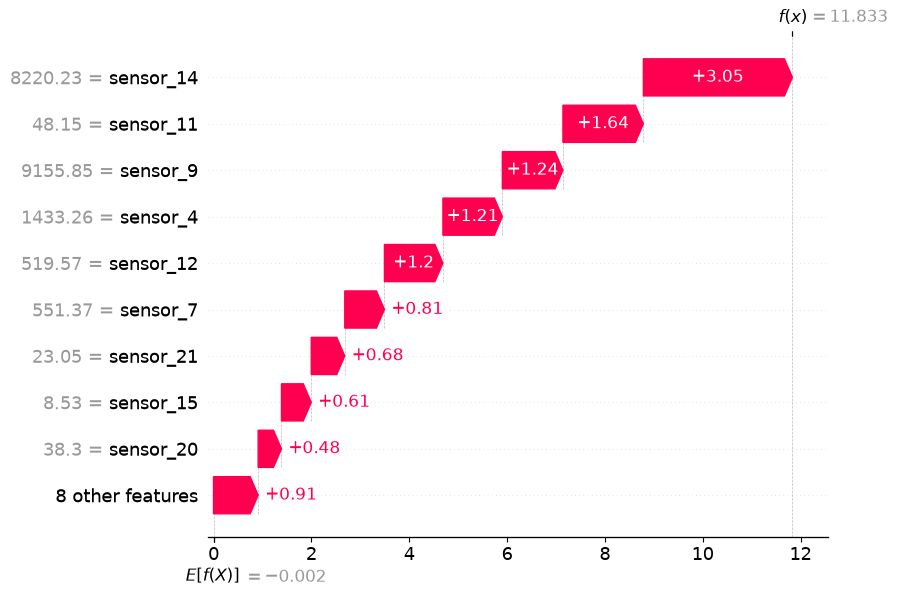

In [13]:
idx = explain.highest_confidence_failure(clf, X_test)
probs = clf.predict_proba(X_test)[:, 1]
print(f"Row {idx}: predicted fail probability = {probs[idx]:.3f}")
print(f"Actual label: {y_test.reset_index(drop=True)[idx]}")

explanation = shap.Explanation(
    values=shap_values[idx],
    base_values=explainer.expected_value,
    data=X_test.reset_index(drop=True).iloc[idx],
    feature_names=feature_cols,
)
shap.plots.waterfall(explanation)

## 9. Takeaways

- **Leakage-safe, engine-level splitting** is essential — and tested.
- On imbalanced maintenance data, **recall on the failure class** is the metric
  that matters; accuracy alone is misleading.
- `scale_pos_weight` corrects for rare failures, yielding high recall at the
  cost of some precision — usually the right trade for maintenance.
- **SHAP** turns a black-box score into something an engineer can act on, both
  globally (what matters overall) and locally (why *this* engine, now).

**Caveat:** C-MAPSS is clean simulated data, so scores are optimistic. Real
sensor data is noisier and scores are typically lower — the *techniques*
transfer, the easy numbers don't.

### Possible extensions
- Predict exact RUL (regression) or time-to-failure (survival analysis / CoxPH)
- Interactive Streamlit demo for per-engine explanations
- Extend to FD002–FD004 (multiple operating conditions)